In [122]:
import pandas as pd
import numpy as np

In [123]:
# 1 Get wave 10 mortality data since wave 6 

#load wave 10 HCAP data  Healthy Cognitive Ageing Project https://www.elsa-project.ac.uk/hcap
fname = "C:/Users/dinab/Desktop/PostDoc/ELSA files/UKDA-5050-stata/stata/stata13_se/elsa_endoflife_hcap2_w10.dta"
df3 = pd.read_stata(fname)

# get ID, date of death and age at death
df3_short = df3[["idauniq", "eidatey", "eirage"]].copy()


In [124]:
# save this in a separate file w10_dod.csv 
df3_short.to_csv("C:/Users/dinab/Desktop/PhD Projects/Ensemble methods/GitHub_App/medicaljourneys/ELSA data/w10_dod.csv")

In [125]:
# 2 Merge with other data to add mortality up to the wave 8 in the main file 
fname0 = "C:/Users/dinab/Desktop/PhD Projects/Ensemble methods/GitHub_App/medicaljourneys/ELSA data/ELSA_short_df.csv"
df = pd.read_csv(fname0)

In [126]:
df.loc[df.idauniq == 162358, :]

,Unnamed: 0,idauniq,yob,yod,sex,eth,edu,wealth,date1,date2,...,psych_wave9,fallinj_wave1,fallinj_wave2,fallinj_wave3,fallinj_wave4,fallinj_wave5,fallinj_wave6,fallinj_wave7,fallinj_wave8,fallinj_wave9
16478,16478,162358,1937.0,NaN,0,0.0,2.0,3.0,2002.663,2004.967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [127]:
df_merged = df.merge(df3_short, on = "idauniq", how = "left")

In [137]:
df_merged['yod'] = df_merged['yod'].fillna(df_merged['eidatey'])

In [157]:
df_merged['died'] = df_merged['died'].fillna(df_merged['eirage'])
df_merged.loc[df_merged['died'] == 'Age of 90 or over collapsed to avoid disclosure', 'died'] = 91

C:\Users\dinab\AppData\Local\Temp\ipykernel_27752\3600050958.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged['died'] = df_merged['died'].fillna(df_merged['eirage'])


In [159]:
df_merged["died"]= df_merged["died"].astype("float")

In [174]:
df_merged.loc[df_merged['yod'] == "Don't know", "yod"] = 2020
#df_merged['yod'] = df_merged['yod'].astype("float")

In [178]:
df_merged.yod.value_counts()

yod
2008.0    140
2006.0    129
2005.0    129
2010.0     87
2004.0     81
2007.0     66
2009.0     58
2011.0     49
2012.0     48
2003.0     47
2020.0     46
2021.0     38
2022.0     28
2019.0     27
2018.0     20
2002.0     14
2023.0     12
2017.0      5
2000.0      1
2016.0      1
Name: count, dtype: int64

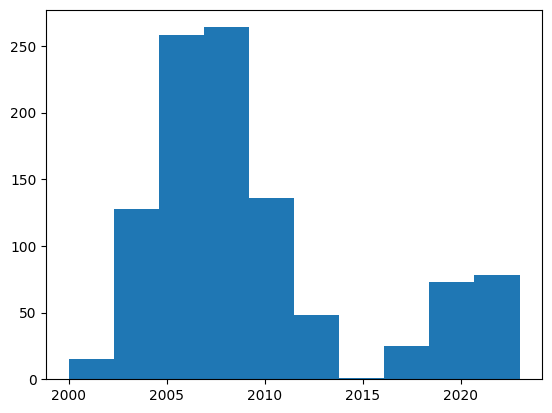

In [180]:
import matplotlib.pyplot as plt

plt.hist(df_merged["yod"])
plt.show()

In [181]:
# 3 Add mortality from wave 10 main file too  
df_d

,idauniq,r10iwstat,r1iwstat,r2iwstat,r3iwstat,r4iwstat,r5iwstat,r6iwstat,r7iwstat,r8iwstat,r9iwstat,first_dead
0,100001,"9.nr, dk if alive or died",0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","4.nr, alive","1.resp, alive","9.nr, dk if alive or died","9.nr, dk if alive or died",NaN
1,100005,"9.nr, dk if alive or died",0.inap.,0.inap.,0.inap.,0.inap.,"1.resp, alive","4.nr, alive","4.nr, alive","4.nr, alive","1.resp, alive",NaN
2,100006,"9.nr, dk if alive or died",0.inap.,0.inap.,0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","9.nr, dk if alive or died","9.nr, dk if alive or died","9.nr, dk if alive or died",NaN
3,100007,"9.nr, dk if alive or died",0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive",NaN
4,100009,"9.nr, dk if alive or died",0.inap.,0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","4.nr, alive","1.resp, alive",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
21674,947649,"1.resp, alive",0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,NaN
21675,947652,"1.resp, alive",0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,NaN
21676,947661,"1.resp, alive",0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,NaN
21677,947665,"1.resp, alive",0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,NaN


In [182]:
df_merged.columns


Index(['Unnamed: 0', 'idauniq', 'yob', 'yod', 'sex', 'eth', 'edu', 'wealth',
       'date1', 'date2',
       ...
       'fallinj_wave2', 'fallinj_wave3', 'fallinj_wave4', 'fallinj_wave5',
       'fallinj_wave6', 'fallinj_wave7', 'fallinj_wave8', 'fallinj_wave9',
       'eidatey', 'eirage'],
      dtype='object', length=101)

In [183]:
df_merged.date9

0        2018.971
1        2019.080
2        2018.971
3        2019.000
4        2018.750
           ...   
19797    2019.500
19798    2019.250
19799    2019.170
19800    2019.250
19801    2019.250
Name: date9, Length: 19802, dtype: float64

In [255]:
df_d.r7iwstat.value_counts()

r7iwstat
1.resp, alive                9666
9.nr, dk if alive or died    5699
0.inap.                      3195
6.nr, died prev wv           2752
4.nr, alive                   359
7.nr, dropped from samp         8
Name: count, dtype: int64

In [193]:
def get_first_dead_wave(row):
    for i, col in enumerate(iwstat_cols, 1):
        if row[col] == "5.nr, died this wv":
            return i
    return None

def get_2_dead_wave(row):
    for i, col in enumerate(iwstat_cols, 1):
        if row[col] == "6.nr, died prev wv":
            return i-1
    return None

df_d['wave_dead'] = df_d.apply(get_first_dead_wave, axis=1)

df_d['when_dead2'] = df_d.apply(get_2_dead_wave, axis=1)

In [194]:
df_d['wave_dead'].value_counts()

wave_dead
5.0    608
4.0    589
3.0    529
6.0    518
2.0    508
Name: count, dtype: int64

In [195]:
df_merged = df_merged.merge(df_d[['idauniq', 'wave_dead']], on='idauniq', how='left')

In [247]:
df_merged.loc[np.isnan(df_merged.wave_dead)==False, ["idauniq","yod","yob", "wave_dead","wave_dead_yod", "died"]].iloc[1:20,:]

,idauniq,yod,yob,wave_dead,wave_dead_yod,died
49,100067,2005.000,1930.0,3.0,2005.795,75.000
56,100074,2009.907,1930.0,5.0,2009.907,79.907
65,100083,2009.907,1941.0,5.0,2009.907,68.907
100,101534,2011.819,1952.0,6.0,2011.819,59.819
114,101784,2005.795,1942.0,3.0,2005.795,63.795
117,101896,2005.795,1944.0,3.0,2005.795,61.795
118,101955,2011.819,1948.0,6.0,2011.819,63.819
137,102626,2005.000,1926.0,3.0,2005.795,79.000
169,103517,2007.884,1945.0,4.0,2007.884,62.884
173,103713,2011.819,1931.0,6.0,2011.819,80.819


In [212]:
df_merged.loc[df_merged.idauniq == 101784, ].iloc[:, 1:20]

,idauniq,yob,yod,sex,eth,edu,wealth,date1,date2,date3,date4,date5,date6,date7,date8,date9,empl,angina,heartattack
114,101784,1942.0,NaN,1,1.0,NaN,4.0,2002.663,2004.83,2006.795,2008.884,2010.907,2012.819,2014.84,2016.87,2018.971,0.0,NaN,NaN


In [ ]:
# the column wave_dead_yod has the value of the dateN where N is the wave number from wave_dead 
df_merged["wave_dead_yod"] = df_merged.apply(
    lambda row: row[f"date{int(row.wave_dead)}"] if not np.isnan(row.wave_dead) else np.nan,
    axis=1
)

In [214]:
# make this 1 year before:
# lets assume the event was 1 before the question was asked (in the middle of this wave)
df_merged.loc[~df_merged['wave_dead_yod'].isna(), 'wave_dead_yod'] = df_merged.loc[~df_merged['wave_dead_yod'].isna(), 'wave_dead_yod'] - 1

In [216]:
# if there is no "yod", we populate it from wave_dead_yod
df_merged.loc[df_merged['yod'].isna(), 'yod'] = df_merged.loc[df_merged['yod'].isna(), 'wave_dead_yod']

In [220]:
# known mortality events
sum(~np.isnan(df_merged.yod)) #2930

2930

In [241]:
# died - age at death, also populate from wave_dead_yod - yob
df_merged.loc[df_merged['died'].isna(), 'died'] = df_merged.loc[df_merged['died'].isna(), 'wave_dead_yod'] - df_merged.loc[df_merged['died'].isna(), 'yob'] 

In [295]:
# also lets add the last date when we KNOW they are alive
def get_first_alive(row):
    c = [i for i, col in enumerate(iwstat_cols, start=1)  if row[col] == "1.resp, alive"]
    return min(c)
    
def get_last_alive(row):
    c = [i for i, col in enumerate(iwstat_cols, start=1)  if row[col] == "1.resp, alive"]
    return max(c)

df_d["first_wave_respond"] = df_d.apply(get_first_alive, axis=1)
df_d["last_wave_respond"] = df_d.apply(get_last_alive, axis=1)


In [305]:
#sanity check
df_d.loc[10:15, ["first_wave_respond", "last_wave_respond"]+ iwstat_cols]

,first_wave_respond,last_wave_respond,r1iwstat,r2iwstat,r3iwstat,r4iwstat,r5iwstat,r6iwstat,r7iwstat,r8iwstat,r9iwstat,r10iwstat
10,5,10,0.inap.,0.inap.,0.inap.,0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive"
11,3,5,0.inap.,0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","9.nr, dk if alive or died","9.nr, dk if alive or died","9.nr, dk if alive or died","9.nr, dk if alive or died","9.nr, dk if alive or died"
12,3,10,0.inap.,0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive"
13,4,10,0.inap.,0.inap.,0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive"
14,2,10,0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","4.nr, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive"
15,5,7,0.inap.,0.inap.,0.inap.,0.inap.,"1.resp, alive","4.nr, alive","1.resp, alive","9.nr, dk if alive or died","9.nr, dk if alive or died","9.nr, dk if alive or died"


In [308]:
# merge the first and last waves alive into the df_merged
df_merged = df_merged.merge(df_d[["first_wave_respond", "last_wave_respond", "idauniq"]], on='idauniq', how='left')
df_merged = df_merged.merge(df_d[iwstat_cols + ["idauniq"]], on='idauniq', how='left')


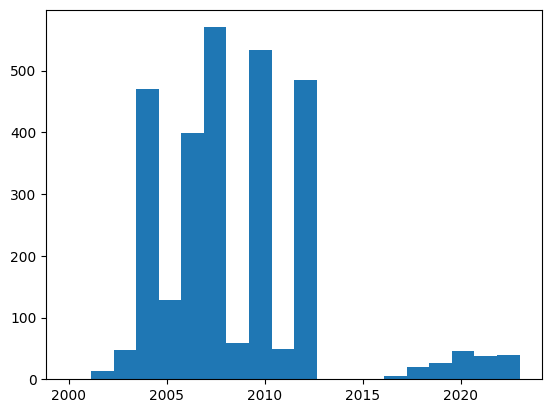

In [246]:
plt.hist(df_merged["yod"],bins = 20)
plt.show()

In [236]:
df_merged.yod.describe()

count    2930.000000
mean     2008.576246
std         4.048817
min      2000.000000
25%      2005.795000
50%      2007.884000
75%      2010.000000
max      2023.000000
Name: yod, dtype: float64

In [466]:
df_merged[["idauniq","first_wave_respond", "last_wave_respond", "yod","first_wave_y", "last_wave_y"]].iloc[18000:18005,:]

,idauniq,first_wave_respond,last_wave_respond,yod,first_wave_y,last_wave_y
18000,167307,7,10,NaN,2014.50,2022.00
18001,167308,7,10,NaN,2015.33,2022.00
18002,167309,7,10,NaN,2014.58,2022.00
18003,167310,7,7,NaN,2014.67,2014.67
18004,167311,7,9,NaN,2015.00,2019.33


In [401]:
# "first_wave_y" column = the date of the wave in first_wave_respond 
def pick_date(row):
    n = row["first_wave_respond"]
    if pd.isna(n):
        return np.nan
    col = f"date{int(n)}"
    return row.get(col, np.nan)

df_merged["first_wave_y"] = df_merged.apply(pick_date, axis=1)

# "last_wave_y" column = the date of the wave in last_wave_respond , 
def pick_date2(row):
    n = row["last_wave_respond"]
    if pd.isna(n):
        return np.nan
    if n == 10:
        return 2022
    col = f"date{int(n)}"      
    return row.get(col, np.nan)

df_merged["last_wave_y"] = df_merged.apply(pick_date2, axis=1)


In [446]:
#add colmns for the start and end age of observation 
df_merged["age_start"]=df_merged["first_wave_y"] - df_merged["yob"]
df_merged["age_end"] = df_merged["last_wave_y"] - df_merged["yob"]
df_merged["age_death" ]  = df_merged["yod"]-df_merged["yob"]

# if death is known, we cut at min(yod-yob, last_wave_y -yob)
mask = df_merged["yod"].notna()
df_merged.loc[mask,"age_end" ] = np.minimum(df_merged.loc[mask,"age_end"], df_merged.loc[mask,"age_death"])
#sometimes the rounding makes end<start, we correct it manually (e.g. death is at 68, start 68.3)
df_merged["age_end"] = np.maximum(df_merged.age_start, df_merged.age_end)



In [478]:
df_merged.loc[(df_merged.last_wave_y > df_merged.yod), ["last_wave_y", "yod", "age_start", "age_end", "age_death","died"]]

,last_wave_y,yod,age_start,age_end,age_death,died
233,2006.58,2006.0,74.42,78.00,78.0,78.0
382,2005.25,2005.0,76.58,79.00,79.0,79.0
386,2004.83,2004.0,82.33,84.00,84.0,84.0
404,2004.58,2004.0,82.33,84.00,84.0,84.0
559,2004.58,2004.0,66.33,68.00,68.0,68.0
...,...,...,...,...,...,...
12306,2007.08,2007.0,88.58,93.00,93.0,93.0
12341,2010.67,2010.0,70.58,78.00,78.0,78.0
14606,2009.08,2009.0,76.08,76.08,76.0,76.0
14804,2019.25,2019.0,55.17,65.00,65.0,69.0


In [488]:
print("check: if died == age_death known, 0 is ok:", sum((~df_merged.died.isna() & df_merged.age_death.isna())))
print("check2: if died == age_death known:",sum((~df_merged.died.isna() & df_merged.age_death.isna())))

check: if died == age_death known, 0 is ok: 0
check2: if died == age_death known: 0


## SAVE

In [472]:
# SAVE 
fname = "C:/Users/dinab/Desktop/PhD Projects/Ensemble methods/GitHub_App/medicaljourneys/ELSA data/ELSA_short_df_w10.csv"
df_merged.to_csv(fname)

In [493]:
fname = "C:/Users/dinab/Desktop/PhD Projects/Ensemble methods/GitHub_App/medicaljourneys/ELSA data/ELSA_short_df_w10.csv"
df_merged = pd.read_csv(fname)

C:\Users\dinab\AppData\Local\Temp\ipykernel_27752\250113573.py:2: DtypeWarning: Columns (100,101) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged = pd.read_csv(fname)


# Create (update) long format

In [494]:
#1) define which events we make into the long format
events = ['angina', 'heartattack', 'chf', 'diabetes', 'stroke', 'arthritis', 'cancer',
           'parkinson', 'psych', 'last_period', 'alzheimer', 'dementia', 'depression', 
           'lung', 'hibp', 'diab', 'cancr', 'strok', 'arthr', 'asthma', 'catract', 'parkin', 'hip', 
           'angin', 'hrtatt', 'hrtrhm', 'hrtmr', 'osteo', 'hyster', 'hchol', 'child_infect', 'child_asthma',
             'child_resp', 'child_allerg', 'child_hdache', 'child_epilepsy', 'child_psych', 'child_bones',
               'child_appdcts', 'child_diab', 'child_heart', 'child_leuk', 'child_cancer', 'angin_wave1', 
               'angin_wave2', 'angin_wave3', 'angin_wave4', 'angin_wave5', 'angin_wave6', 'angin_wave7',
                 'angin_wave8', 'angin_wave9', 'hrtatt_wave1', 'hrtatt_wave2', 'hrtatt_wave3', 'hrtatt_wave4',
                   'hrtatt_wave5', 'hrtatt_wave6', 'hrtatt_wave7', 'hrtatt_wave8', 'hrtatt_wave9', 'psych_wave1', 
                   'psych_wave2', 'psych_wave3', 'psych_wave4', 'psych_wave5', 'psych_wave6', 'psych_wave7', 
                   'psych_wave8', 'psych_wave9', 
                   'fallinj_wave1', 'fallinj_wave2', 'fallinj_wave3', 'fallinj_wave4', 'fallinj_wave5', 'fallinj_wave6',
                     'fallinj_wave7', 'fallinj_wave8', 'fallinj_wave9',
                       'died', 'born']

# 2) add event "born" at the age of 0
df_merged["born"]=0

# 3) "melt" the df_merged by idauniq for separate row for each event with value going into the "age" 
# (value in events are the ages at which this happened)
long_df = df_merged[events + ["idauniq"]].melt(id_vars=['idauniq'], var_name='event', value_name='age').dropna()
long_df = long_df.sort_values(by=['idauniq', 'age']) 
long_df.index = range(1, len(long_df) + 1) #row names to 1 2. ... 

# 4) add context variables 
long_df = long_df.merge(df_merged[['idauniq', 'sex', 'wealth', 'edu', 'eth']], on='idauniq', how='left')
long_df = long_df.sort_values(['idauniq','age'])

In [495]:
# 5) add age_start and age_end 
long_df = long_df.merge(df_merged[['idauniq', 'age_start',"age_end"]], on='idauniq', how='left')

In [522]:
long_df.loc[long_df.idauniq == 100078, :]

,idauniq,event,age,sex,wealth,edu,eth,age_start,age_end
317,100078,born,0.0,0,3.0,2.0,0.0,60.0,60.0


In [532]:
long_df.loc[long_df.idauniq == 100065, :]

,idauniq,event,age,sex,wealth,edu,eth,age_start,age_end
240,100065,born,0.00,0,3.0,3.0,0.0,50.5,53.33
241,100065,hibp,49.50,0,3.0,3.0,0.0,50.5,53.33
242,100065,osteo,49.50,0,3.0,3.0,0.0,50.5,53.33
243,100065,hchol,52.33,0,3.0,3.0,0.0,50.5,53.33


In [520]:
long_df.loc[long_df.event == "last_period", : ].iloc[1:5, ]

,idauniq,event,age,sex,wealth,edu,eth,age_start,age_end
137,100045,last_period,51.0,1,1.000000,1.0,1.0,67.58,84.08
157,100048,last_period,38.0,1,1.000000,1.0,0.0,35.08,54.00
184,100052,last_period,54.0,1,1.555556,3.0,0.0,51.58,68.17
216,100059,last_period,50.0,1,2.400000,2.0,0.0,67.67,75.58


In [533]:
# Changing child events to non-child events (such that cancer is still cancer irrespective of the age)
# Mapping all by groups 
# remove duplicates 
# remove those with only "born" 

In [534]:
# mapping leuk, cancr and child_cancer to "cancer" etc. 
events_grouping = {
    # from earliest age at which diagnosed 
    "angina" : "cvd","heartattack" : "cvd","chf" : "cvd","diabetes" : "diabetes","stroke" : "cvd",
    "arthritis" : "arthritis","cancer" : "cancer","parkinson" : "parkinson","psych" : "psych",
    "last_period" : "last_period","alzheimer" : "dem_alzheimer","dementia" : "dem_alzheimer",
    "depression" : "depression","died" : "died",                
    "lung" : "asthma_respir","hibp" : "bones","diab" : "diabetes","cancr" : "cancer",
    "heart" : "remove!","strok" : "cvd","arthr" : "arthritis", "asthma" : "asthma_respir","catract" : "eye",
    "parkin" : "parkinson","hip" : "bones","angin" : "cvd", "hrtatt" : "cvd","hrtrhm" : "cvd",
    "hrtmr" : "cvd","osteo" : "bones","hyster" : "hysterectomy","hchol" : "cholesterol",
    
    # from "ever had " questions 
    "child_infect" : "remove!","child_asthma" : "asthma_respir","child_resp" : "asthma_respir",
    "child_allerg" : "remove!","child_hdache" : "remove!","child_epilepsy" : "psych","child_psych" : "psych",
    "child_bones" : "bones","child_appdcts" : "remove!","child_diab" : "diabetes","child_heart" : "cvd",
    "child_leuk" : "cancer","child_cancer" : "cancer",
     
    # from childhood health questionnaire with random 1-16 age 
    "angin_wave1" : "cvd","angin_wave2" : "cvd", "angin_wave3" : "cvd","angin_wave4" : "cvd","angin_wave5" : "cvd",
    "angin_wave6" : "cvd", "angin_wave7" : "cvd","angin_wave8" : "cvd","angin_wave9" : "cvd",
    "hrtatt_wave1" : "cvd","hrtatt_wave2" : "cvd","hrtatt_wave3" : "cvd","hrtatt_wave4" : "cvd","hrtatt_wave5" : "cvd",
    "hrtatt_wave6" : "cvd", "hrtatt_wave7" : "cvd","hrtatt_wave8" : "cvd","hrtatt_wave9" : "cvd",

    # from repeated questions "have you had in the past 2 years?" 
    "psych_wave1" : "psych","psych_wave2" : "psych","psych_wave3" : "psych","psych_wave4" : "psych","psych_wave5" : "psych",
    "psych_wave6" : "psych","psych_wave7" : "psych","psych_wave8" : "psych","psych_wave9" : "psych",
    
    "fallinj_wave1" : "bones","fallinj_wave2" : "bones","fallinj_wave3" : "bones","fallinj_wave4" : "bones",
    "fallinj_wave5" : "bones","fallinj_wave6" : "bones","fallinj_wave7" : "bones","fallinj_wave8" : "bones","fallinj_wave9" : "bones"
} 

In [535]:
new_events  = long_df['event'].replace(events_grouping)
print("Number of events, original = ", len(new_events.unique())) 
print("Number of events, re-mapped = ", len(long_df['event'].unique())) # 80 -> 18
print(new_events.unique())

# keep all events in "event_all" and new_events in "event" column
long_df["event_all"] = long_df["event"].copy()
long_df["event"] = new_events

Number of events, original =  17
Number of events, re-mapped =  80
['born' 'diabetes' 'bones' 'cholesterol' 'arthritis' 'psych'
 'asthma_respir' 'remove!' 'eye' 'cvd' 'cancer' 'last_period'
 'hysterectomy' 'died' 'depression' 'dem_alzheimer' 'parkinson']


In [536]:
# remove "remove!" conditions
long_df = long_df.loc[long_df.event !="remove!", :]

In [537]:
# remove duplicated events (if were in several places, e.g. "ever" and "last 2y" or in "earliest age")
long_df["patid"] = long_df["idauniq"].copy()
print(len(long_df[long_df[["patid", "age", "event"]].duplicated()]))
long_df = long_df[["patid", "age", "event","sex", "wealth", "edu", "eth"]].drop_duplicates(keep='first')
long_df.shape # 110484 7

7427


(105423, 7)

In [538]:
# removing those with ONLY 1 record ("born"), about 2.2k people 
temp = pd.DataFrame(long_df.groupby("patid").count() == 1)["age"]*1  #can take any column, e.g. "age" here 
print("Number of people with only 1 record", sum(temp)) # 2239 
long_df = long_df[long_df['patid'].map(long_df['patid'].value_counts()) > 1]

Number of people with only 1 record 2370


Number of records per person


<Axes: >

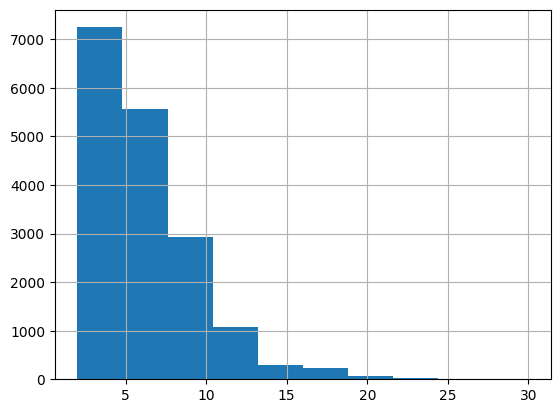

In [539]:
print ("Number of records per person")
long_df['patid'].value_counts().hist()

In [540]:
#take the earliest age ONLY for some diagnoses
first_only = ["parkinson", "diabetes", "dem_alzheimer", "cancer", "hysterectomy", "arthritis"]

# make sure we are sorted by age within a patient
long_df = long_df.sort_values(['patid','age'])

# create row with rownumbers to drop some later 
long_df["rowid"] = range(len(long_df.patid))

# cycle over first-only conditions and get the list of "rowid" corresponding to duplicated rows 
# (in a sense of same first-only conditions for the same patient)
i = np.empty(0, dtype = int)
for idx in range(len(first_only)):
    d1 = long_df[long_df.event == first_only[idx]].duplicated(subset=['patid', 'event'], keep='first')
    i1 = long_df[long_df.event == first_only[idx]][d1]["rowid"] #get rowids to delete, duplicated for the same condition
    i = np.concatenate((i, i1))
i = np.unique(i) #these are all to delete

print (long_df.shape)
# now disselect those rowids 
long_df = long_df[~long_df['rowid'].isin(i)]
print (long_df.shape)

(103053, 8)
(92090, 8)


In [541]:
long_df.loc[long_df.patid == 909775, :] #example - should be only one arthritis at 16 yo

,patid,age,event,sex,wealth,edu,eth,rowid
121335,909775,0.00,born,1,1.0,1.0,0.0,103048
121336,909775,16.00,arthritis,1,1.0,1.0,0.0,103049
121338,909775,51.25,cvd,1,1.0,1.0,0.0,103051
121340,909775,51.25,cholesterol,1,1.0,1.0,0.0,103052


AttributeError: 'DataFrame' object has no attribute 'bmi'

In [542]:
# SAVE THE DATA
print("Final dim", long_df.shape) #Final dim (89873, 8)
long_df.to_csv("ELSA data\ELSA_long_df_w11.csv") 

<>:3: SyntaxWarning: invalid escape sequence '\E'
<>:3: SyntaxWarning: invalid escape sequence '\E'
C:\Users\dinab\AppData\Local\Temp\ipykernel_27752\2595737572.py:3: SyntaxWarning: invalid escape sequence '\E'
  long_df.to_csv("ELSA data\ELSA_long_df_w11.csv")


Final dim (92090, 8)


In [549]:
c = df3.columns

In [550]:
c[1:10]

Index(['wave', 'mainpilot', 'intdatmm', 'intdatyy', 'eidatlamm', 'eidatlayy',
       'eirrelm', 'eirfri', 'survsp'],
      dtype='object')

In [551]:
bmi_cols = [col for col in df3.columns if 'bmi' in col.lower()]
print(bmi_cols)

[]
